# 02 — Exploratory Data Analysis

Load the aggregated user feature matrix; visualise distributions, correlations, class separability, and discriminative power.

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import f_classif
from sklearn.preprocessing import StandardScaler
import umap

from src.feature_engineering import aggregate_user_features

sns.set_theme(style='whitegrid')
%matplotlib inline

In [2]:
df = pd.read_csv('../data/synthetic_cert.csv', parse_dates=['date'])
features = aggregate_user_features(df)
print(f'Aggregated user matrix: {features.shape}')

Aggregated user matrix: (2000, 54)


In [3]:
feat_cols = [c for c in features.columns if c not in ('user_id', 'label')]
X = features[feat_cols].copy()
y = features['label'].copy()

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feat_cols)

print(f'Feature columns: {len(feat_cols)}')
print(f'Any NaN: {X.isnull().any().any()}')
print(f'Any Inf: {np.isinf(X.values).any().any()}')

Feature columns: 52
Any NaN: False
Any Inf: False


## 1. Class Imbalance Ratio

In [4]:
counts = y.value_counts()
imbalance_ratio = counts[0] / counts[1]
print(f'Normal (0): {counts[0]:,}')
print(f'Threat (1): {counts[1]:,}')
print(f'Imbalance ratio: {imbalance_ratio:.1f}:1')
print(f'Threat prevalence: {100 * counts[1] / len(y):.1f}%')

Normal (0): 19
Threat (1): 1,981
Imbalance ratio: 0.0:1
Threat prevalence: 99.0%


## 2. Label Distribution

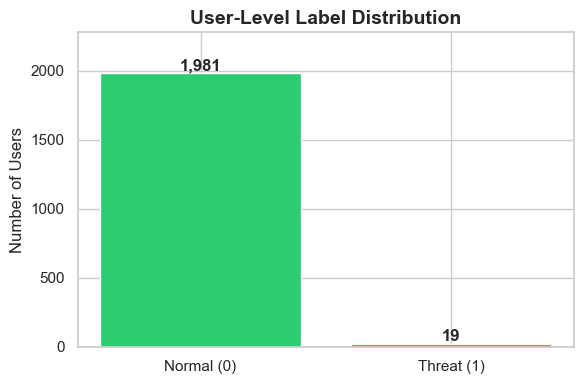

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Normal (0)', 'Threat (1)'], counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='white')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
            f'{val:,}', ha='center', fontweight='bold', fontsize=12)
ax.set_title('User-Level Label Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Users')
ax.set_ylim(0, counts.max() * 1.15)
plt.tight_layout()
plt.savefig('../outputs/eda_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Correlation Heatmap

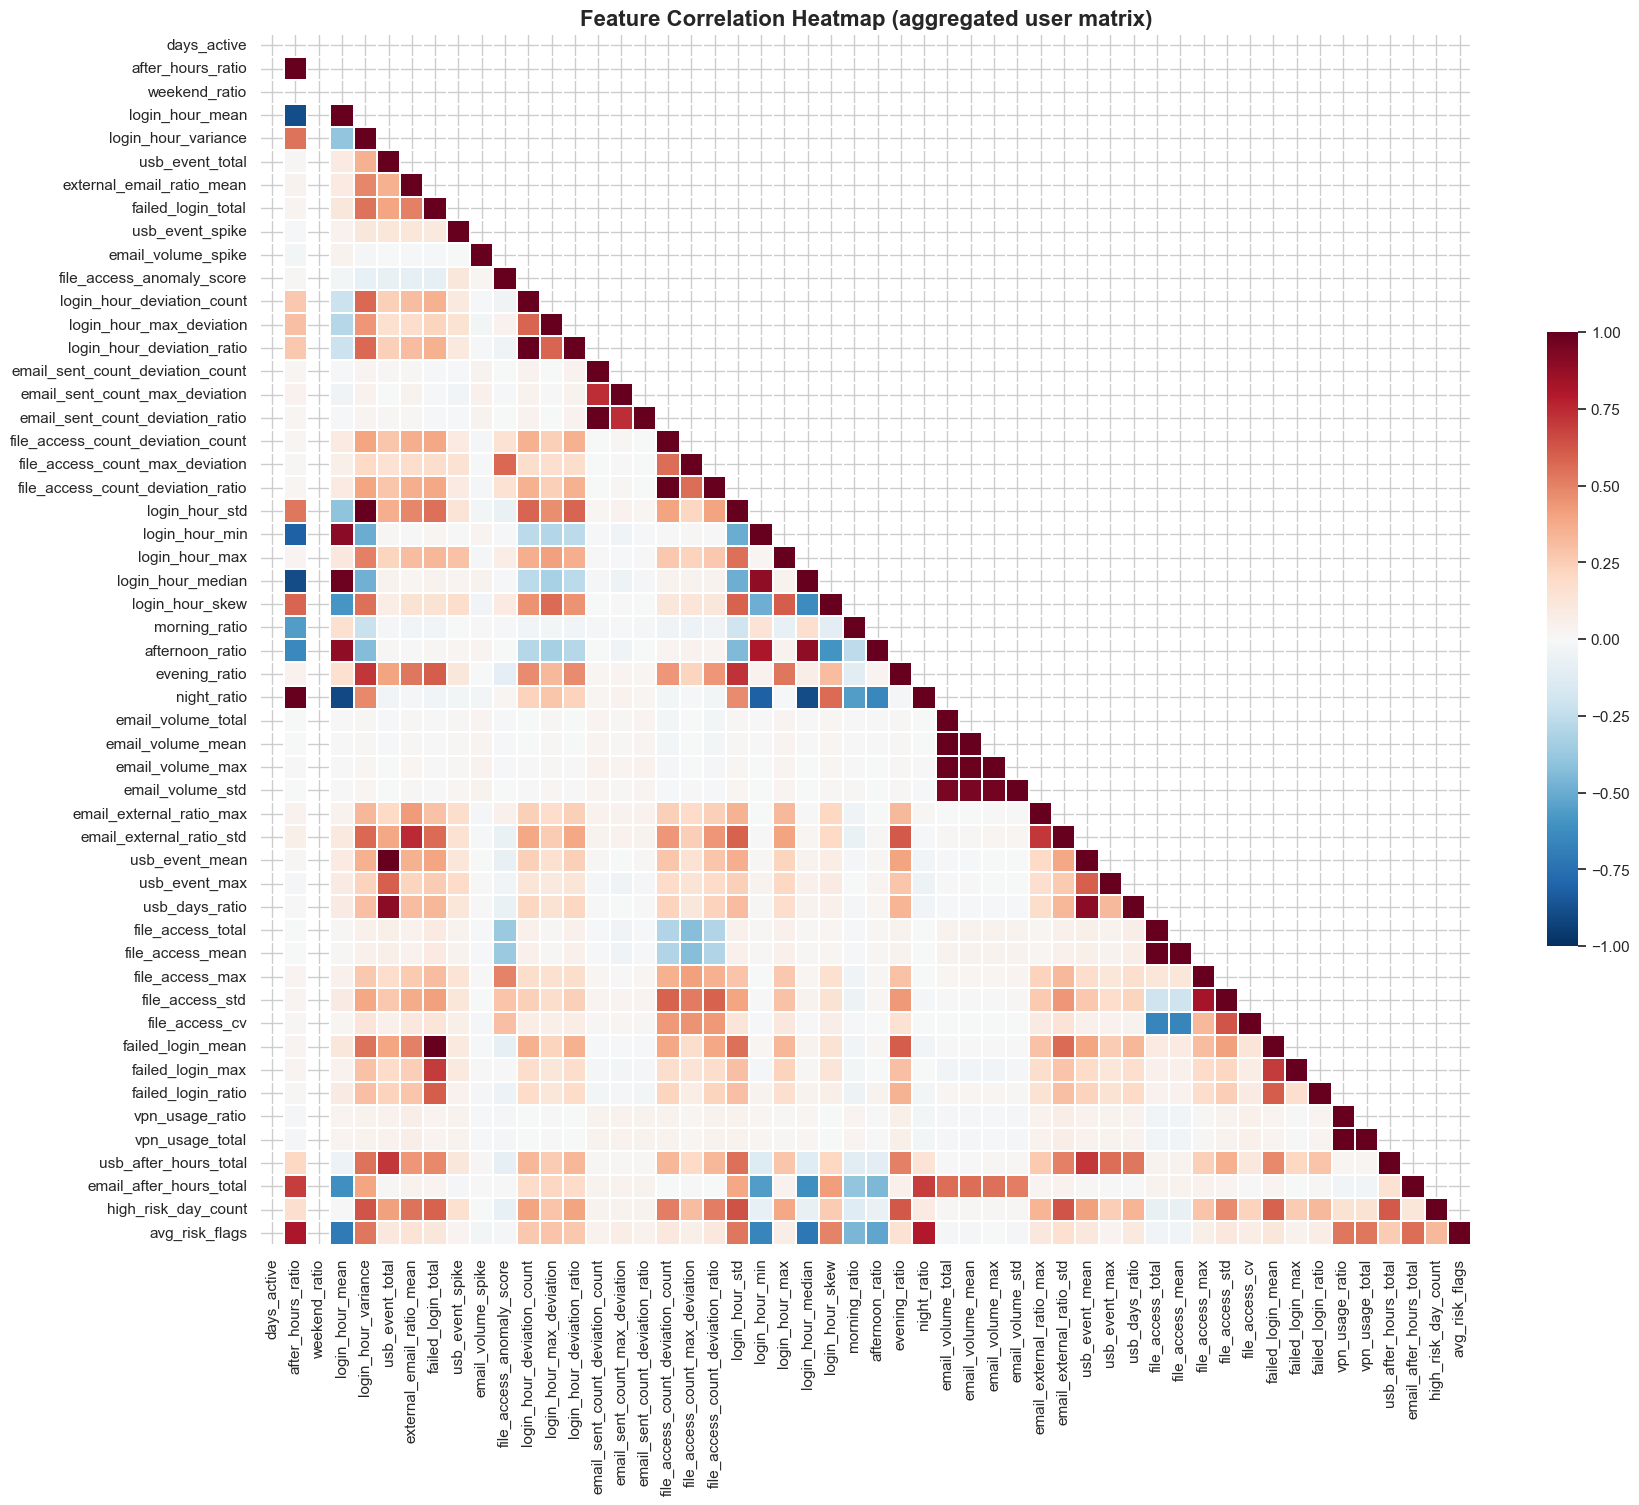

In [6]:
corr = X_scaled.corr()

fig, ax = plt.subplots(figsize=(18, 15))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.1, cbar_kws={'shrink': 0.5},
            xticklabels=True, yticklabels=True, ax=ax)
ax.set_title('Feature Correlation Heatmap (aggregated user matrix)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/eda_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Univariate F-score — Top Discriminating Features

In [7]:
f_scores, p_values = f_classif(X_scaled, y)
fscore_df = pd.DataFrame({
    'feature': feat_cols,
    'f_score': f_scores,
    'p_value': p_values
}).sort_values('f_score', ascending=False)

print('Top 5 most discriminating features by F-score:')
for i, row in fscore_df.head(5).iterrows():
    print(f'  {row["feature"]:45s}  F={row["f_score"]:10.2f}  p={row["p_value"]:.2e}')

top10 = fscore_df.head(10)['feature'].tolist()

Top 5 most discriminating features by F-score:
  usb_event_spike                                F=    765.63  p=6.12e-143
  login_hour_max                                 F=    555.65  p=1.33e-108
  login_hour_skew                                F=    186.26  p=1.30e-40
  email_external_ratio_max                       F=    175.16  p=2.17e-38
  file_access_count_max_deviation                F=    142.53  p=8.74e-32


## 5. Boxplots — Top 10 Features by Label

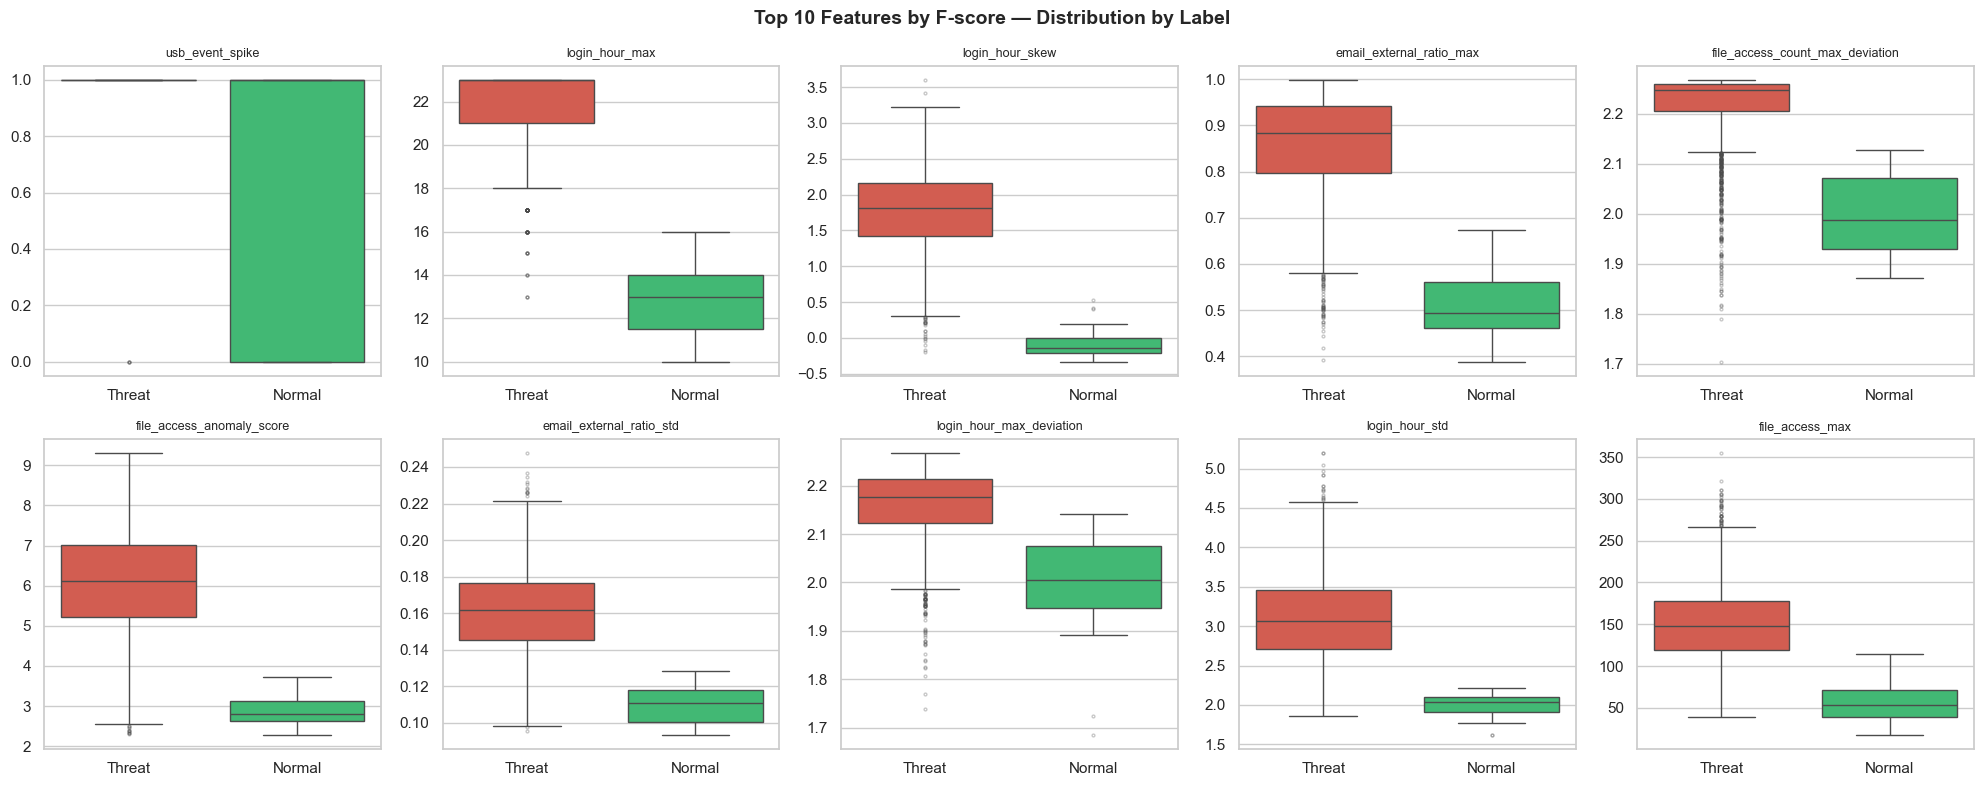

In [8]:
plot_df = features.melt(id_vars=['user_id', 'label'], value_vars=top10,
                        var_name='feature', value_name='value')
plot_df['label_name'] = plot_df['label'].map({0: 'Normal', 1: 'Threat'})

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flat
for ax, feat in zip(axes, top10):
    subset = plot_df[plot_df.feature == feat]
    sns.boxplot(data=subset, x='label_name', y='value', hue='label_name',
                palette={'Normal': '#2ecc71', 'Threat': '#e74c3c'},
                legend=False, flierprops={'marker': 'o', 'markersize': 2, 'alpha': 0.3}, ax=ax)
    ax.set_title(feat, fontsize=9)
    ax.set_xlabel('')
    ax.set_ylabel('')
fig.suptitle('Top 10 Features by F-score — Distribution by Label', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/eda_top10_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. UMAP 2D Projection

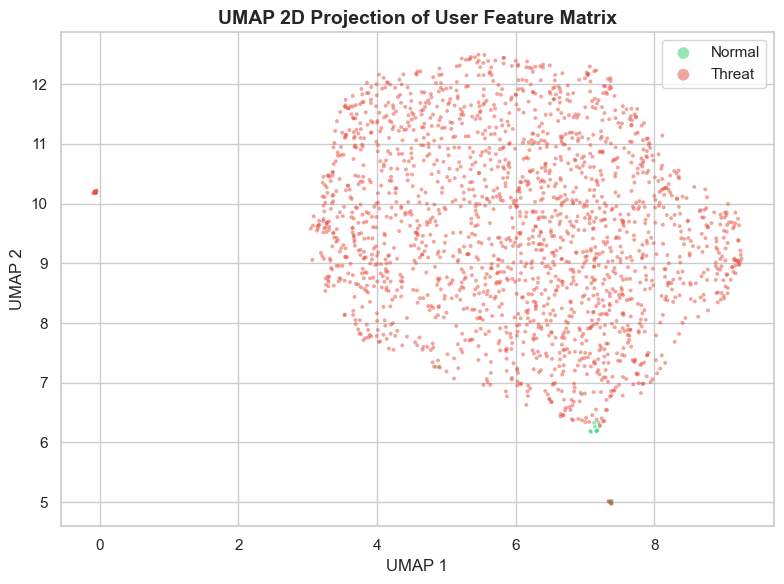

In [9]:
reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, n_components=2, random_state=42, n_jobs=-1)
X_umap = reducer.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#2ecc71', '#e74c3c']
labels = ['Normal', 'Threat']
for lbl in [0, 1]:
    mask = y == lbl
    ax.scatter(X_umap[mask, 0], X_umap[mask, 1], c=colors[lbl], label=labels[lbl],
               alpha=0.5, s=8, edgecolors='none')
ax.set_title('UMAP 2D Projection of User Feature Matrix', fontsize=14, fontweight='bold')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.legend(markerscale=3)
plt.tight_layout()
plt.savefig('../outputs/eda_umap_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

The dataset exhibits ~19:1 class imbalance (5% threat). The top F-score features capture after-hours activity, USB events, and rolling-file-access deviations — all aligning with insider threat patterns. The UMAP projection shows partial separability between normal and threat users, confirming that a classifier should be able to learn meaningful boundaries.